<a href="https://colab.research.google.com/github/TomerL44/CloudCompEX/blob/main/Tirgul5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HTTP status: 200
{'diseas': 60}
0.9833333333333333
{'detect': 15}
0.9333333333333333
{'plant': 32}
0.96875
{'speci': 9}
0.8888888888888888
{'choic': 5}
0.8
{'perform': 23}
0.9565217391304348
{'crop': 35}
0.9714285714285714
{'accuraci': 28}
0.9642857142857143
{'diagnos': 2}
0.5
{'architectur': 22}
0.9545454545454546


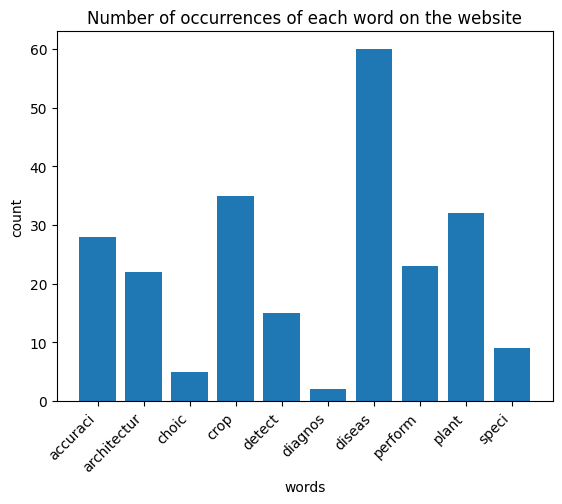

In [52]:
!pip install firebase
import re
from nltk.stem import PorterStemmer
!pip install requests beautifulsoup4
import requests
from bs4 import BeautifulSoup
from firebase import firebase
import time
import matplotlib.pyplot as plt





#Initialize Firebase connection
FBconn = firebase.FirebaseApplication('https://tirgul5-ee2ed-default-rtdb.firebaseio.com/', None)

url = "https://pmc.ncbi.nlm.nih.gov/articles/PMC5032846/"

def update_word(word, count):
    word = word.lower().strip()
    if not word:
        return
    FBconn.put('/words/', word, count)



def fetch_page(url):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        )
    }



    try:
        response = requests.get(url, headers=headers)
        print("HTTP status:", response.status_code)

        if response.status_code == 200:
            soup = BeautifulSoup(response.text, "html.parser")
            return soup
        else:
            print("Response head:", response.text[:200])
            return None

    except Exception as e:
        print("Request error:", e)
        return None


def index_words(soup):
  index = {}
  words = re.findall(r'\w+', soup.get_text())
  for word in words:
    word = word.lower()
    if word in index:
      index[word] += 1
    else:
      index[word] = 1
  return index

def remove_stop_words(index):
  stop_words = {'a', 'an', 'the', 'and', 'or', 'in', 'on', 'at'}
  for stop_word in stop_words:
    if stop_word in index:
      del index[stop_word]
  return index


def search(query, index):
  stemmer = PorterStemmer()
  query_words = re.findall(r'\w+', query.lower())
  results = {}
  for word in query_words:
    word = stemmer.stem(word)
    if word in index:
      results[word] = index[word]
  return results

def apply_stemming(index):
    stemmer = PorterStemmer()
    stemmed_index = {}
    for word, count in index.items():
      stemmed_word = stemmer.stem(word)
      if stemmed_word in stemmed_index:
        stemmed_index[stemmed_word] += count
      else:
        stemmed_index[stemmed_word] = count
    return stemmed_index



def search_engine(soup, query):
    if soup is None:
        return None
    index = index_words(soup)
    index = remove_stop_words(index)
    index = apply_stemming(index)
    results = search(query, index)
    return results






Words = ["Disease", "Detection", "Plant", "species", "Choice", "performance", "crop", "accuracy", "diagnoses", "architecture"]


soup = fetch_page(url)

for word in Words:
  results = search_engine(soup, word)
  print(results)
  rank=1
  for key, count in results.items():
    update_word(key,count)
    rank = rank*1/count
  rank = 1-rank
  print(rank)





def get_all_records():
    """Retrieve all Word records"""
    return FBconn.get('/words/', None)



all_words = get_all_records()

if all_words:
    words_list = list(all_words.keys())
    counts_list = list(all_words.values())

plt.bar(words_list, counts_list)
plt.xlabel('words')
plt.ylabel('count')
plt.title('Number of occurrences of each word on the website')
plt.xticks(rotation=45, ha='right')
plt.show()













